<a href="https://colab.research.google.com/github/alinelima1909/Atividade-notas-dos-alunos_desafio1_python-colab/blob/main/02_analise_exploratoria_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/Mental Health Dataset.csv')
df.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


Dimensão do Dataset

In [3]:
df.shape


(292364, 17)

Tipos de Dados

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292364 entries, 0 to 292363
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Timestamp                292364 non-null  object
 1   Gender                   292364 non-null  object
 2   Country                  292364 non-null  object
 3   Occupation               292364 non-null  object
 4   self_employed            287162 non-null  object
 5   family_history           292364 non-null  object
 6   treatment                292364 non-null  object
 7   Days_Indoors             292364 non-null  object
 8   Growing_Stress           292364 non-null  object
 9   Changes_Habits           292364 non-null  object
 10  Mental_Health_History    292364 non-null  object
 11  Mood_Swings              292364 non-null  object
 12  Coping_Struggles         292364 non-null  object
 13  Work_Interest            292364 non-null  object
 14  Social_Weakness     

Estatistica Geral

In [5]:
df.describe(include='all')


,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
count,292364,292364,292364,292364,287162,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364
unique,580,2,35,5,2,2,2,5,3,3,3,3,2,3,3,3,3
top,8/27/2014 11:43,Male,United States,Housewife,No,No,Yes,1-14 days,Maybe,Yes,No,Medium,No,No,Maybe,No,No
freq,2384,239850,171308,66351,257994,176832,147606,63548,99985,109523,104018,101064,154328,105843,103393,232166,118886


Código para padronizar todas as colunas

In [6]:
import unicodedata

#remover os acentos
def remover_acentos(texto): return unicodedata.normalize('NFKD', texto).encode('ASCII', 'ignore').decode('utf-8')
# aplicar padronização
df.columns = (
    df.columns
    .str.strip()               # remove espaços extras
    .str.lower()               # minúsculo
    .map(remover_acentos)      # remove acentos
    .str.replace(' ', '_')     # troca espaço por _
)
df.columns



Index(['timestamp', 'gender', 'country', 'occupation', 'self_employed',
       'family_history', 'treatment', 'days_indoors', 'growing_stress',
       'changes_habits', 'mental_health_history', 'mood_swings',
       'coping_struggles', 'work_interest', 'social_weakness',
       'mental_health_interview', 'care_options'],
      dtype='object')

In [7]:

df.rename(columns={
    'quantidade_de_internamentos': 'qtd_internamentos'
}, inplace=True)


Verificação de Valores Nulos

In [8]:
# O DataFrame 'df' não está definido na sessão atual.
# Por favor, certifique-se de que todas as células anteriores, especialmente a que carrega o CSV, foram executadas.
df.isnull().sum()

,0
timestamp,0
gender,0
country,0
occupation,0
self_employed,5202
family_history,0
treatment,0
days_indoors,0
growing_stress,0
changes_habits,0


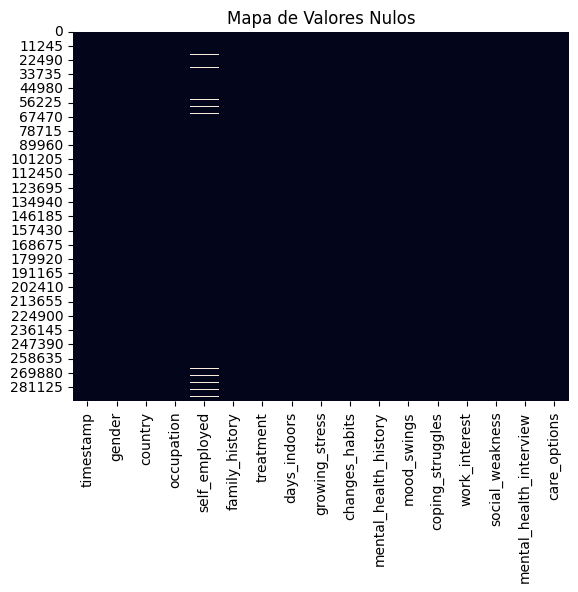

In [15]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Mapa de Valores Nulos")
plt.show()


Análise das Variáveis Numéricas

In [18]:
# O DataFrame 'df' não possui colunas numéricas para serem descritas ou para plotar um histograma.
# df.select_dtypes(include=np.number).describe()
# plt.figure()
# df['qtd_internamentos'].hist()
# plt.title("Distribuição - Quantidade de Internamentos")
# plt.xlabel("Quantidade")
# plt.ylabel("Frequência")
# plt.show()

# As colunas do DataFrame são todas do tipo 'object'.
# Se houver uma coluna que deveria ser numérica (e que não foi convertida),
# você precisaria fazer essa conversão antes de tentar descrevê-la ou plotá-la.
# Além disso, a coluna 'qtd_internamentos' não existe no DataFrame.
# Você pode verificar as colunas disponíveis com df.columns

Análise das Variávies das  Categorias

In [19]:
df.select_dtypes(include='object').columns


Index(['timestamp', 'gender', 'country', 'occupation', 'self_employed',
       'family_history', 'treatment', 'days_indoors', 'growing_stress',
       'changes_habits', 'mental_health_history', 'mood_swings',
       'coping_struggles', 'work_interest', 'social_weakness',
       'mental_health_interview', 'care_options'],
      dtype='object')

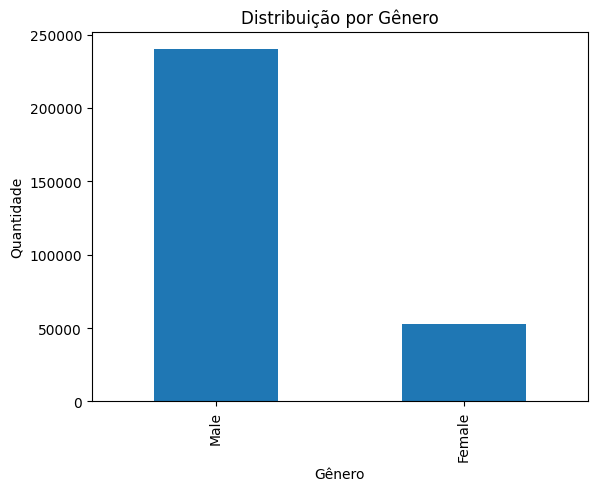

In [20]:
plt.figure()
df['gender'].value_counts().plot(kind='bar')
plt.title("Distribuição por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Quantidade")
plt.show()


Correlação entre as Variáveis Numéricas

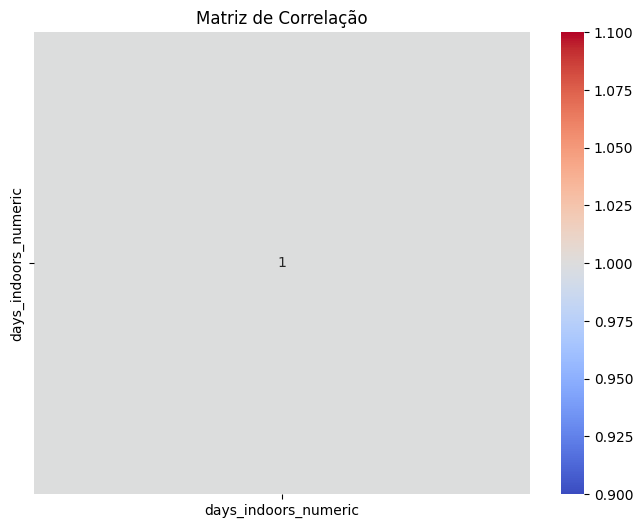

In [22]:
# Converter a coluna 'days_indoors' para um tipo numérico
# Mapear as categorias para um valor numérico médio da faixa ou um valor representativo
mapping_days_indoors = {
    '1-14 days': 7,       # Ponto médio da faixa
    '15-30 days': 22.5,   # Ponto médio da faixa
    '31-60 days': 45.5,   # Ponto médio da faixa
    '61-90 days': 75.5,   # Ponto médio da faixa
    '> 90 days': 100      # Valor representativo para 'mais de 90 dias'
}
df['days_indoors_numeric'] = df['days_indoors'].map(mapping_days_indoors)

# Agora, gere o mapa de calor com a nova coluna numérica
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Matriz de Correlação")
plt.show()

Análises Cruzadas

In [27]:
df.groupby('gender')['days_indoors_numeric'].mean()

,days_indoors_numeric
gender,
Female,25.548638
Male,24.652720


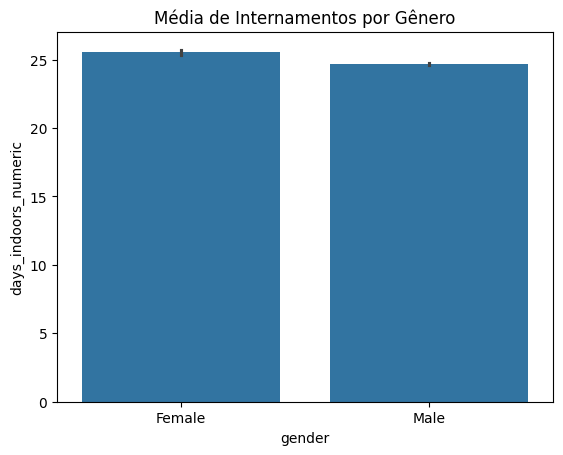

In [29]:
plt.figure()
sns.barplot(x='gender', y='days_indoors_numeric', data=df)
plt.title("Média de Internamentos por Gênero")
plt.show()


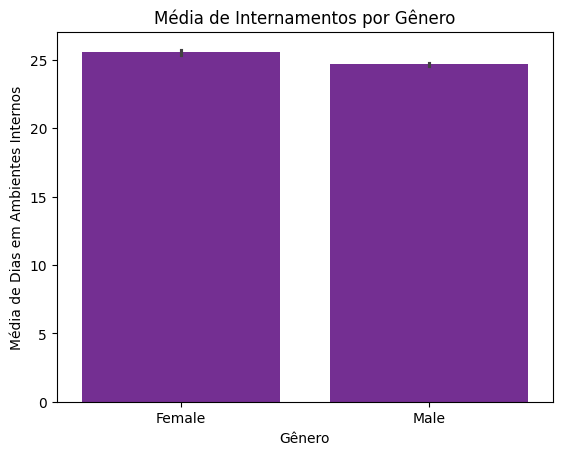

In [32]:
plt.figure()
sns.barplot(
    x='gender',
    y='days_indoors_numeric',
    data=df,
    color='#7B1FA2'   # roxo profissional
)
plt.title("Média de Internamentos por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Média de Dias em Ambientes Internos")
plt.show()